In [1]:
import sympy as sm
import scqubits as scq

import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

# Ideal 1-mode GKP Hamiltonian

Ideal GKP Hamiltonian
$E_C (\hat n - n_g)^2 + \frac{1}{2} E_{L} \hat \varphi^2 - E_{S} \cos(2\pi \hat n) + E_{2J} \cos(2 (\hat \varphi+ \phi_{\text{ext}}))$

In [8]:
symbolic_hamiltonian = sm.parse_expr(
    "EC*(Q1 - ng1)**2 + 1/2*EL*θ1**2 - ES*cos(2*pi*Q1) + E2J*cos(2*(θ1+Φ1))"
)
gkp_ideal = scq.Circuit(
    symbolic_hamiltonian=symbolic_hamiltonian,
    symbolic_param_dict={"EC":0.2, "EL":0.2, "ES":4, "E2J":10},
    ext_basis="harmonic",
)

gkp_ideal

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Circuit_3

check truncation convergence

Spectral data:   0%|          | 0/8 [00:00<?, ?it/s]

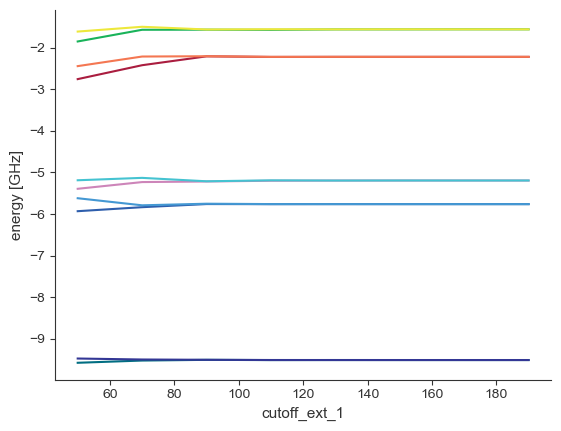

CPU times: total: 21.5 s
Wall time: 692 ms


In [9]:
%%time

gkp_ideal.plot_evals_vs_paramvals('cutoff_ext_1',range(50,200,20),subtract_ground=False,evals_count=10)
plt.show();

spectrum versus $\phi_{\text{ext}}$

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

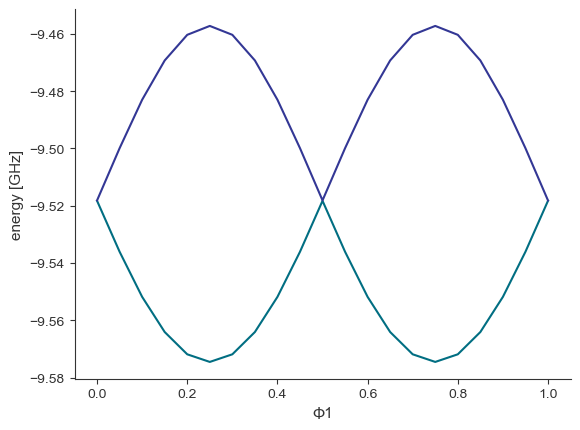

CPU times: total: 1min 12s
Wall time: 2.37 s


In [10]:
%%time
gkp_ideal.ng1, gkp_ideal.cutoff_ext_1=0, 150

gkp_ideal.plot_evals_vs_paramvals('Φ1', np.linspace(0,1,21),subtract_ground=False,evals_count=2)
plt.show();

spectrum versus $n_{g1}$

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

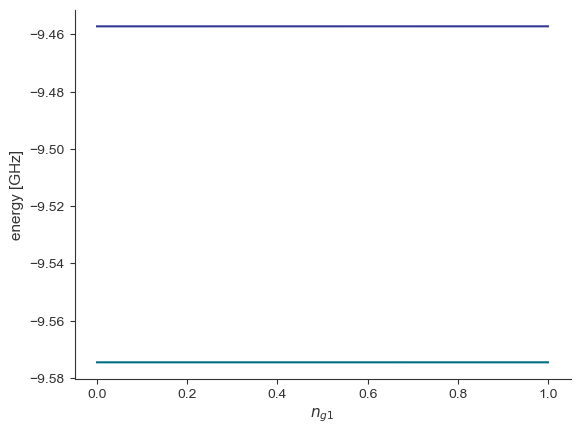

CPU times: total: 1min 20s
Wall time: 2.62 s


In [11]:
%%time
gkp_ideal.Φ1, gkp_ideal.cutoff_ext_1=0.25, 150

gkp_ideal.plot_evals_vs_paramvals('ng1', np.linspace(0,1,21),subtract_ground=False,evals_count=2)
plt.show();

increase $E_C$ to see more dispersion

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

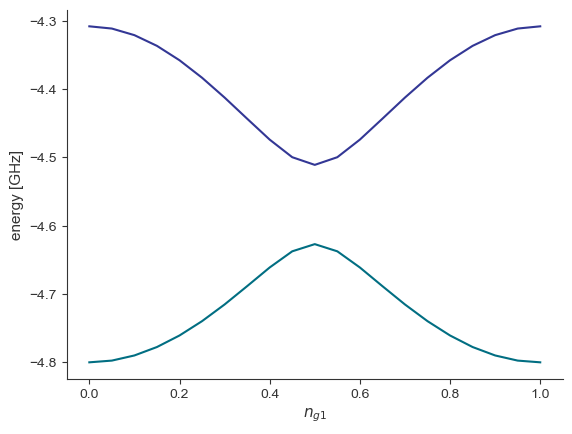

CPU times: total: 1min 9s
Wall time: 2.23 s


In [14]:
%%time
gkp_ideal.Φ1, gkp_ideal.cutoff_ext_1, gkp_ideal.EC=0.25, 150, 3

gkp_ideal.plot_evals_vs_paramvals('ng1', np.linspace(0,1,21),subtract_ground=False,evals_count=2)
plt.show();

matrix elements of the phase operators

In [22]:
gkp_ideal.operators_by_name

{'ad1_operator': <bound method operator_func_factory.<locals>.operator_func of Circuit_3>,
 'a1_operator': <bound method operator_func_factory.<locals>.operator_func of Circuit_3>,
 'Nh1_operator': <bound method operator_func_factory.<locals>.operator_func of Circuit_3>,
 'θ1_operator': <bound method operator_func_factory.<locals>.operator_func of Circuit_3>,
 'sinθ1_operator': <bound method operator_func_factory.<locals>.operator_func of Circuit_3>,
 'cosθ1_operator': <bound method operator_func_factory.<locals>.operator_func of Circuit_3>,
 'Q1_operator': <bound method operator_func_factory.<locals>.operator_func of Circuit_3>,
 'I_operator': <bound method CircuitRoutines._identity of Circuit_3>}

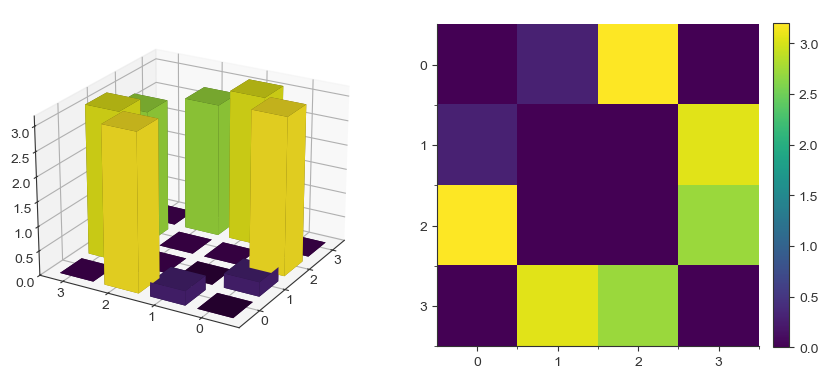

CPU times: total: 8.03 s
Wall time: 285 ms


In [25]:
%%time
gkp_ideal.Φ1, gkp_ideal.ng1, gkp_ideal.cutoff_ext_1=0, 0, 150

gkp_ideal.plot_matrixelements('θ1_operator',evals_count=4)
plt.show();

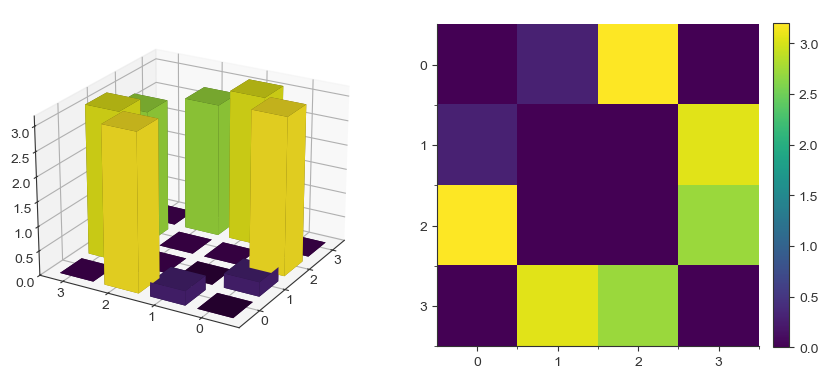

CPU times: total: 8.03 s
Wall time: 285 ms


In [25]:
%%time
gkp_ideal.Φ1, gkp_ideal.ng1, gkp_ideal.cutoff_ext_1=0, 0, 150

gkp_ideal.plot_matrixelements('θ1_operator',evals_count=4)
plt.show();

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

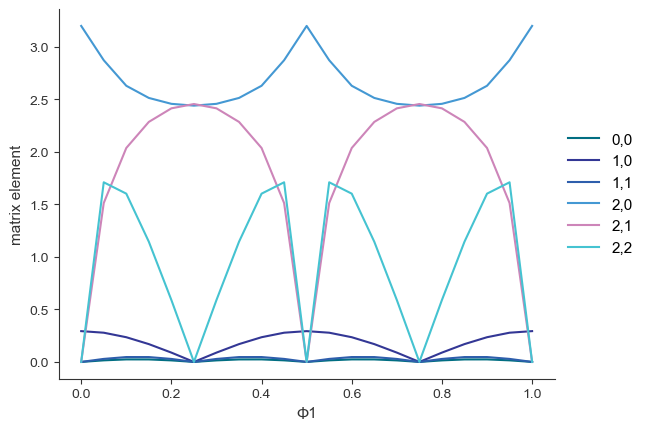

In [29]:
gkp_ideal.ng1, gkp_ideal.cutoff_ext_1= 0, 150
gkp_ideal.plot_matelem_vs_paramvals('θ1_operator', 'Φ1', np.linspace(0,1,21), select_elems=3);
plt.show();

# 3-mode Gridium circuit

In [32]:
gkp_3mode_yaml = """branches:
- [JJ, 0,1, EJ=4, EC=0.5]
- [JJ, 0,2, EJ, EC]
- [L, 1,4, El=0.3]
- [L, 2,4, El]
- [L, 3,4, EL=0.3]
- [JJ, 0,3, 4, 6]
"""
gkp_3mode = scq.Circuit(gkp_3mode_yaml, from_file=False, ext_basis = "discretized")

trans_mat =  np.array([[1., 0., 0., 0.],
                       [1., 1., 0., 0.],
                       [1., 1., 1., 0.],
                       [1., 0., 0., 1.]])

gkp_3mode.configure(transformation_matrix=trans_mat, closure_branches=[gkp_3mode.branches[1], gkp_3mode.branches[-1]])
gkp_3mode.cutoff_n_1, gkp_3mode.cutoff_ext_2, gkp_3mode.cutoff_ext_3 = 5, 200, 200

gkp_3mode.configure(system_hierarchy=[[1, 2], [3]], subsystem_trunc_dims=[50, 20])

gkp_3mode.Φ1, gkp_3mode.ng1 = 0.25, 0

gkp_3mode

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Circuit_5

check truncation convergence

In [33]:
gkp_3mode.cutoff_names

['cutoff_n_1', 'cutoff_ext_2', 'cutoff_ext_3']

Spectral data:   0%|          | 0/7 [00:00<?, ?it/s]

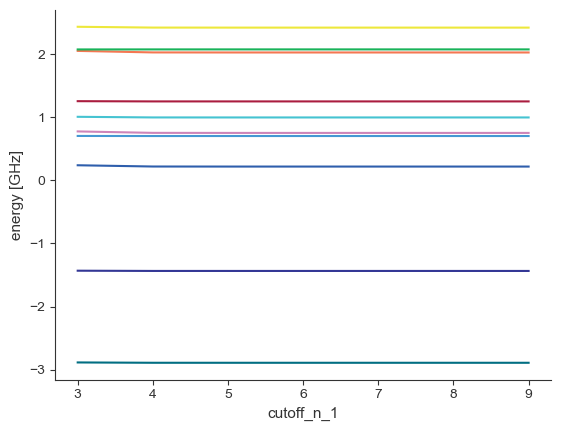

CPU times: total: 8min 6s
Wall time: 16.5 s


In [34]:
%%time

gkp_3mode.plot_evals_vs_paramvals('cutoff_n_1',range(3,10,1),subtract_ground=False,evals_count=10)
plt.show();

Spectral data:   0%|          | 0/5 [00:00<?, ?it/s]

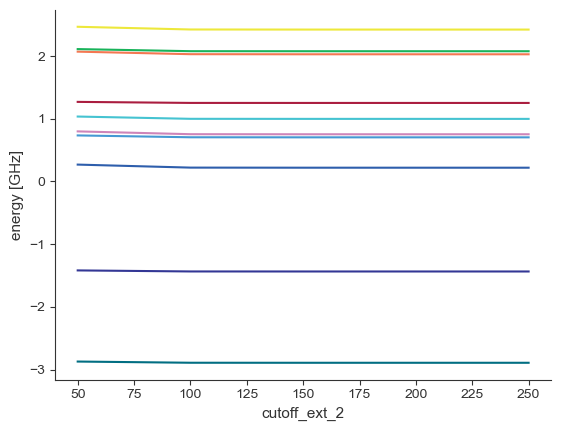

CPU times: total: 3min 55s
Wall time: 8.17 s


In [35]:
%%time

gkp_3mode.plot_evals_vs_paramvals('cutoff_ext_2',range(50,300,50),subtract_ground=False,evals_count=10)
plt.show();

Spectral data:   0%|          | 0/5 [00:00<?, ?it/s]

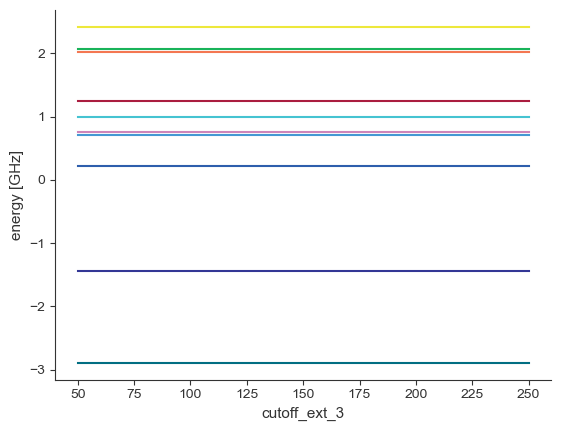

CPU times: total: 2min 22s
Wall time: 5.17 s


In [36]:
%%time

gkp_3mode.plot_evals_vs_paramvals('cutoff_ext_3',range(50,300,50),subtract_ground=False,evals_count=10)
plt.show();

spectrum versus $\theta_{\text{ext}}$ at $\phi_{\text{ext}}=0$

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

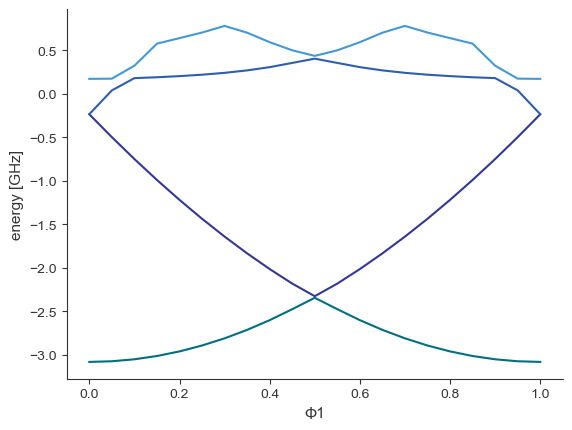

CPU times: total: 21min 21s
Wall time: 44.5 s


In [38]:
%%time
gkp_3mode.Φ2 = 0

gkp_3mode.plot_evals_vs_paramvals('Φ1', np.linspace(0,1,21),subtract_ground=False,evals_count=4)
plt.show();

spectrum versus $\phi_{\text{ext}}$ at $\theta_{\text{ext}}=0$

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

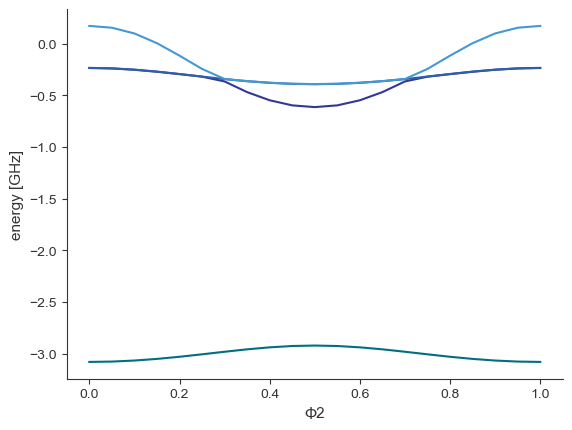

CPU times: total: 6min 47s
Wall time: 17.9 s


In [39]:
%%time
gkp_3mode.Φ1 = 0

gkp_3mode.plot_evals_vs_paramvals('Φ2', np.linspace(0,1,21),subtract_ground=False,evals_count=4)
plt.show();

spectrum versus $\phi_{\text{ext}}$ at $\theta_{\text{ext}}=\pi$

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

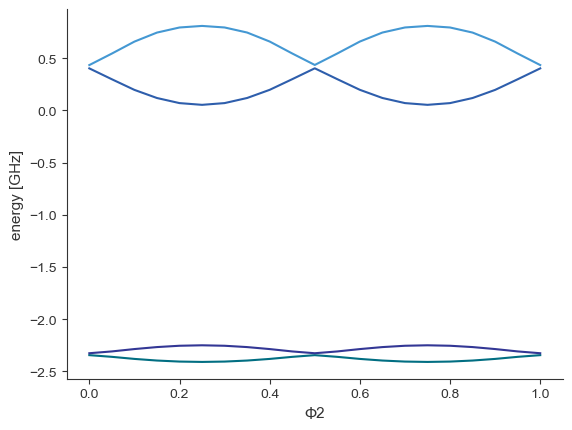

CPU times: total: 6min 43s
Wall time: 17.5 s


In [40]:
%%time
gkp_3mode.Φ1 = 1/2

gkp_3mode.plot_evals_vs_paramvals('Φ2', np.linspace(0,1,21),subtract_ground=False,evals_count=4)
plt.show();

# 4-mode Gridium circuit

In [41]:
#eC: charging energy across the KITE loop
#eP: charging energy across the outer loop

gkp_4mode_yaml = """branches:
- [JJ, 0,1, EJ=4, EC=0.5]
- [JJ, 0,2, EJ, EC]
- [C, 1,2, eC=5.5] 
- [C, 0,4, eP=10]
- [L, 1,4, El=0.3]
- [L, 2,4, El]
- [L, 3,4, EL=0.3]
- [JJ, 0,3, 4, 6]
"""
gkp_4mode = scq.Circuit(gkp_4mode_yaml, from_file=False, ext_basis = "discretized")

trans_mat =  np.array([[1., 0., 0., 0.],
                       [1., 1., 0., 0.],
                       [1., 1., 1., 0.],
                       [1., 0., 0., 1.]])

gkp_4mode.configure(transformation_matrix=trans_mat, closure_branches=[gkp_4mode.branches[1], gkp_4mode.branches[-1]])
gkp_4mode.cutoff_n_1, gkp_4mode.cutoff_ext_2, gkp_4mode.cutoff_ext_3, gkp_4mode.cutoff_ext_4 = 5, 200, 200, 200

gkp_4mode.configure(system_hierarchy=[[[1, 2], [4]],[3]], subsystem_trunc_dims=[[125,[100,15]],15])

gkp_4mode.Φ1, gkp_4mode.Φ2, gkp_4mode.ng1 = 0.25, 0, 0

gkp_4mode

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Circuit_6

In [42]:
gkp_4mode.cutoff_names

['cutoff_n_1', 'cutoff_ext_2', 'cutoff_ext_3', 'cutoff_ext_4']

Spectral data:   0%|          | 0/7 [00:00<?, ?it/s]

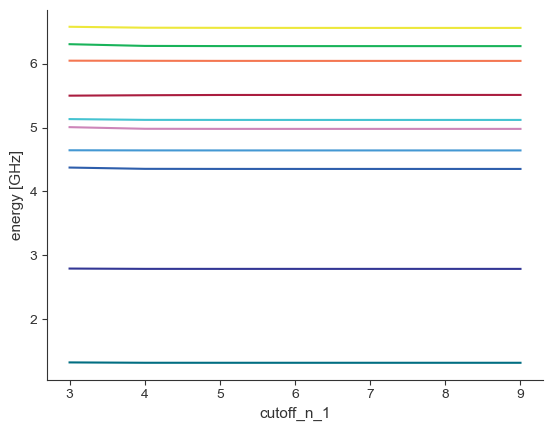

CPU times: total: 28min 36s
Wall time: 1min 8s


In [43]:
%%time

gkp_4mode.plot_evals_vs_paramvals('cutoff_n_1',range(3,10,1),subtract_ground=False,evals_count=10)
plt.show();

Spectral data:   0%|          | 0/5 [00:00<?, ?it/s]

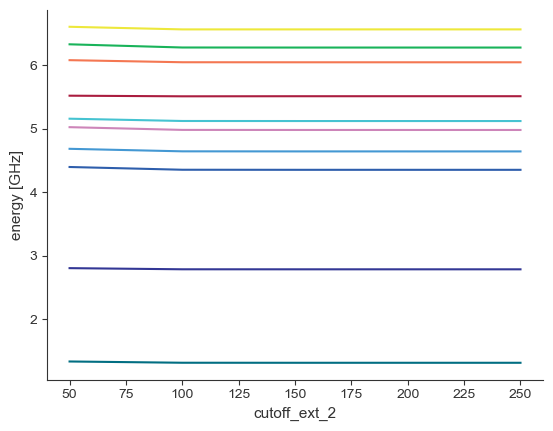

CPU times: total: 16min 50s
Wall time: 41.6 s


In [44]:
%%time

gkp_4mode.plot_evals_vs_paramvals('cutoff_ext_2',range(50,300,50),subtract_ground=False,evals_count=10)
plt.show();

Spectral data:   0%|          | 0/5 [00:00<?, ?it/s]

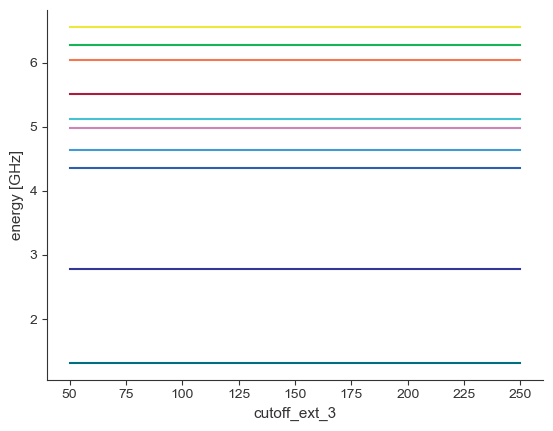

CPU times: total: 7min 36s
Wall time: 23.2 s


In [45]:
%%time

gkp_4mode.plot_evals_vs_paramvals('cutoff_ext_3',range(50,300,50),subtract_ground=False,evals_count=10)
plt.show();

Spectral data:   0%|          | 0/5 [00:00<?, ?it/s]

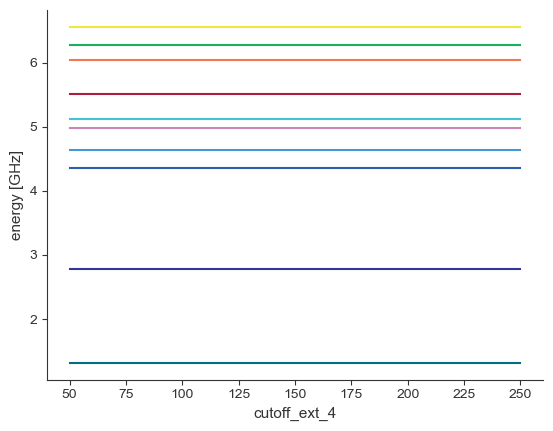

CPU times: total: 11min 48s
Wall time: 31.9 s


In [46]:
%%time

gkp_4mode.plot_evals_vs_paramvals('cutoff_ext_4',range(50,300,50),subtract_ground=False,evals_count=10)
plt.show();

spectrum versus $\theta_{\text{ext}}$ at $\phi_{\text{ext}}=0$

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

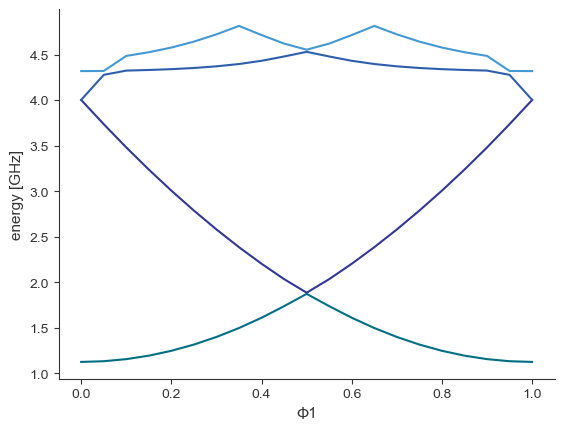

CPU times: total: 1h 18min 59s
Wall time: 3min 9s


In [47]:
%%time
gkp_4mode.Φ2 = 0

gkp_4mode.plot_evals_vs_paramvals('Φ1', np.linspace(0,1,21),subtract_ground=False,evals_count=4)
plt.show();

spectrum versus $\phi_{\text{ext}}$ at $\theta_{\text{ext}}=0$

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

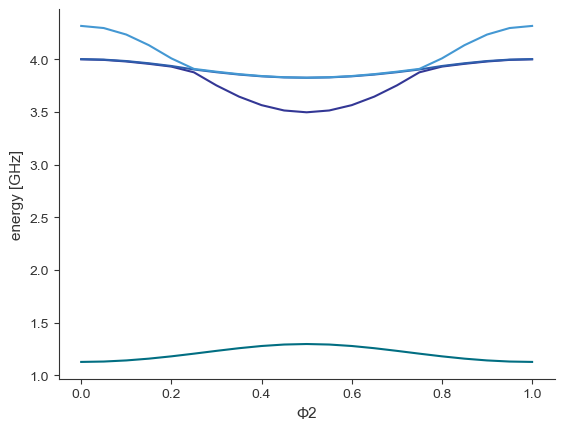

CPU times: total: 16min 55s
Wall time: 1min 14s


In [48]:
%%time
gkp_4mode.Φ1 = 0

gkp_4mode.plot_evals_vs_paramvals('Φ2', np.linspace(0,1,21),subtract_ground=False,evals_count=4)
plt.show();

spectrum versus $\phi_{\text{ext}}$ at $\theta_{\text{ext}}=\pi$

Spectral data:   0%|          | 0/21 [00:00<?, ?it/s]

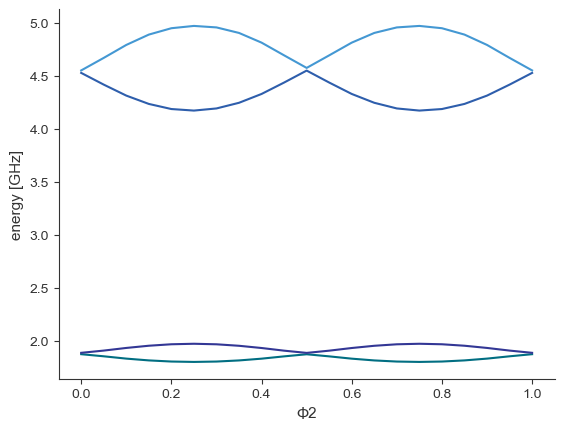

CPU times: total: 23min 2s
Wall time: 1min 17s


In [49]:
%%time
gkp_4mode.Φ1 = 1/2

gkp_4mode.plot_evals_vs_paramvals('Φ2', np.linspace(0,1,21),subtract_ground=False,evals_count=4)
plt.show();